# 5. Exploratory Data Analysis (EDA)

L'EDA (Exploratory Data Analysis) consiste à explorer et analyser les données nettoyées afin de mieux comprendre leur distribution, détecter les valeurs inhabituelles et identifier les relations entre les variables et le temps de livraison.

Nous allons utiliser des statistiques, des regroupements et des visualisations pour découvrir les principaux patterns du dataset.

### 5.1 Vue générale du dataset

Nous commençons par examiner la structure générale du dataset après le nettoyage.

Cette étape permet de vérifier le nombre de lignes et de colonnes, les types des variables et les principales statistiques numériques.

In [2]:
import pandas as pd
import numpy as np

In [3]:
clean_df = pd.read_csv('../data/cleaned_data.csv')
clean_df.head()


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Weatherconditions,Road_traffic_density,Type_of_vehicle,multiple_deliveries,Time_taken(min),distance,order_hour,pickup_hour
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,Sunny,High,motorcycle,0.0,24,3.020737,11.0,11
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,Stormy,Jam,scooter,1.0,33,20.143737,19.0,19
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,Sandstorms,Low,motorcycle,1.0,26,1.549693,8.0,8
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,Sunny,Medium,motorcycle,1.0,21,7.774497,18.0,18
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,Cloudy,High,scooter,1.0,30,6.197898,13.0,13


In [10]:
clean_df.shape


(41522, 15)

In [20]:
clean_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Delivery_person_Age,41522.0,29.568807,5.655790,20.000000,25.000000,30.000000,34.000000,39.000000
Delivery_person_Ratings,41522.0,4.634261,0.321795,1.000000,4.500000,4.700000,4.800000,5.000000
Restaurant_latitude,41522.0,18.896960,5.461033,9.957144,12.986047,19.060834,22.751234,30.914057
Restaurant_longitude,41522.0,76.914307,3.493224,72.768726,73.897902,76.618203,78.368855,88.433452
Delivery_location_latitude,41522.0,18.960623,5.462841,9.967144,13.065662,19.115838,22.818060,31.054057
Delivery_location_longitude,41522.0,76.977970,3.493405,72.778726,73.939315,76.663067,78.403391,88.563452
multiple_deliveries,41522.0,0.750710,0.567383,0.000000,0.000000,1.000000,1.000000,3.000000
Time_taken(min),41522.0,26.315447,9.380634,10.000000,19.000000,26.000000,32.000000,54.000000
distance,41522.0,9.704133,5.593935,1.463837,4.648474,9.177295,13.659637,20.942906
order_hour,41522.0,17.471051,4.746506,0.000000,15.000000,19.000000,21.000000,23.000000


In [21]:
clean_df.duplicated().sum()

np.int64(0)

In [11]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41522 entries, 0 to 41521
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_Age          41522 non-null  float64
 1   Delivery_person_Ratings      41522 non-null  float64
 2   Restaurant_latitude          41522 non-null  float64
 3   Restaurant_longitude         41522 non-null  float64
 4   Delivery_location_latitude   41522 non-null  float64
 5   Delivery_location_longitude  41522 non-null  float64
 6   Order_Date                   41522 non-null  str    
 7   Weatherconditions            41522 non-null  str    
 8   Road_traffic_density         41522 non-null  str    
 9   Type_of_vehicle              41522 non-null  str    
 10  multiple_deliveries          41522 non-null  float64
 11  Time_taken(min)              41522 non-null  int64  
 12  distance                     41522 non-null  float64
 13  order_hour                 

### 5.2 Analyse de la variable cible

La variable cible de notre projet est `Time_taken(min)`, qui représente le temps total nécessaire pour effectuer une livraison.

Nous allons analyser sa distribution et ses statistiques afin de mieux comprendre les temps de livraison dans notre dataset.

In [19]:
clean_df["Time_taken(min)"].describe().T

count    41522.000000
mean        26.315447
std          9.380634
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64

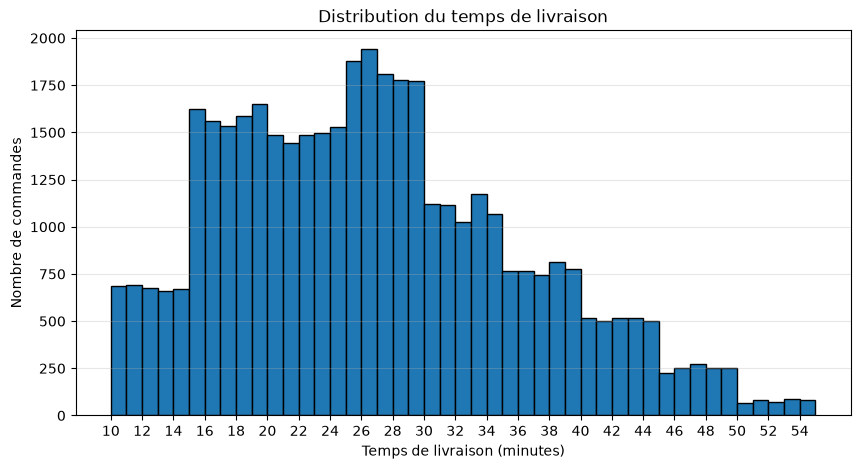

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    clean_df["Time_taken(min)"],
    bins=range(10, 56),
    edgecolor="black"
)

plt.xlabel("Temps de livraison (minutes)")
plt.ylabel("Nombre de commandes")
plt.title("Distribution du temps de livraison")
plt.xticks(range(10, 55, 2))
plt.grid(axis="y", alpha=0.3)

plt.show()

### 5.3 Analyse des variables numériques

Nous allons maintenant analyser les principales variables numériques du dataset.

Cette étape permet d'observer leur distribution, leurs valeurs minimales et maximales, ainsi que d'identifier d'éventuelles valeurs inhabituelles.

In [26]:
numerical_cols = [
    "Delivery_person_Age",
    "multiple_deliveries",
    "order_hour",
    "pickup_hour",
    "distance"
]

clean_df[numerical_cols].describe()

,Delivery_person_Age,multiple_deliveries,order_hour,pickup_hour,distance
count,41522.000000,41522.000000,41522.000000,41522.000000,41522.000000
mean,29.568807,0.750710,17.471051,17.145971,9.704133
std,5.655790,0.567383,4.746506,5.318611,5.593935
min,20.000000,0.000000,0.000000,0.000000,1.463837
25%,25.000000,0.000000,15.000000,14.000000,4.648474
50%,30.000000,1.000000,19.000000,19.000000,9.177295
75%,34.000000,1.000000,21.000000,21.000000,13.659637
max,39.000000,3.000000,23.000000,23.000000,20.942906


### 5.3.1 Distribution de l'âge des livreurs

Nous allons visualiser la distribution de l'âge des livreurs afin d'observer les âges les plus fréquents et la répartition générale de cette variable.

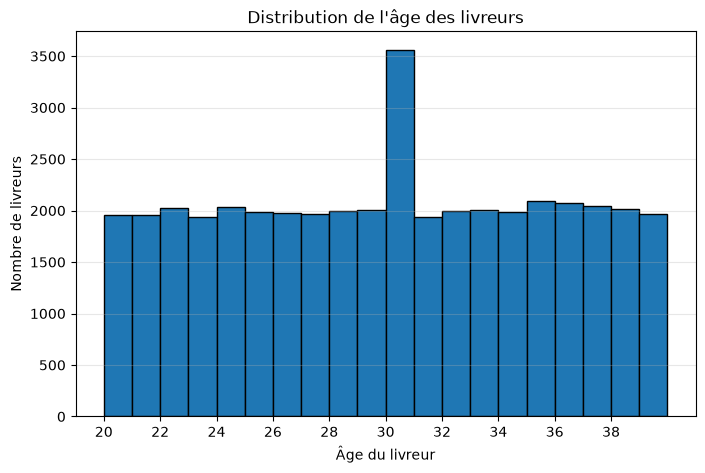

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    clean_df["Delivery_person_Age"],
    bins=range(20, 41),
    edgecolor="black"
)

plt.xlabel("Âge du livreur")
plt.ylabel("Nombre de livreurs")
plt.title("Distribution de l'âge des livreurs")
plt.xticks(range(20, 40, 2))
plt.grid(axis="y", alpha=0.3)

plt.show()

### 5.3.2 Analyse des livraisons multiples

La variable `multiple_deliveries` indique le nombre de livraisons multiples associées à une commande.

Nous allons observer la fréquence de chaque valeur afin de comprendre leur répartition dans le dataset.

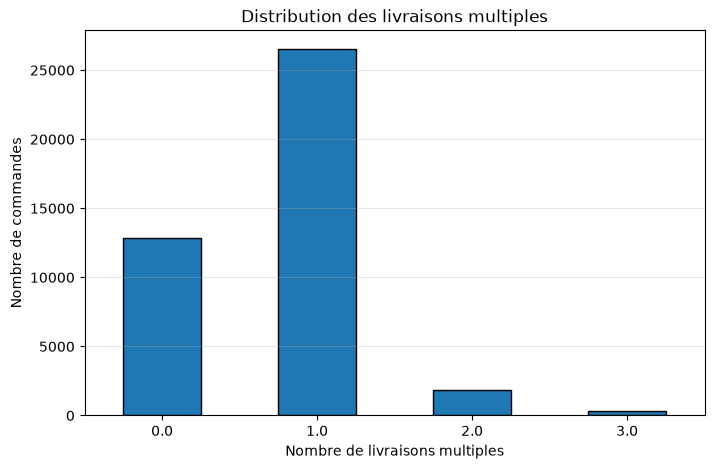

In [31]:
clean_df["multiple_deliveries"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

plt.xlabel("Nombre de livraisons multiples")
plt.ylabel("Nombre de commandes")
plt.title("Distribution des livraisons multiples")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

### 5.3.3 Analyse de l'heure de commande

Nous allons analyser la répartition des commandes selon l'heure de la journée afin d'identifier les périodes où les commandes sont les plus fréquentes.

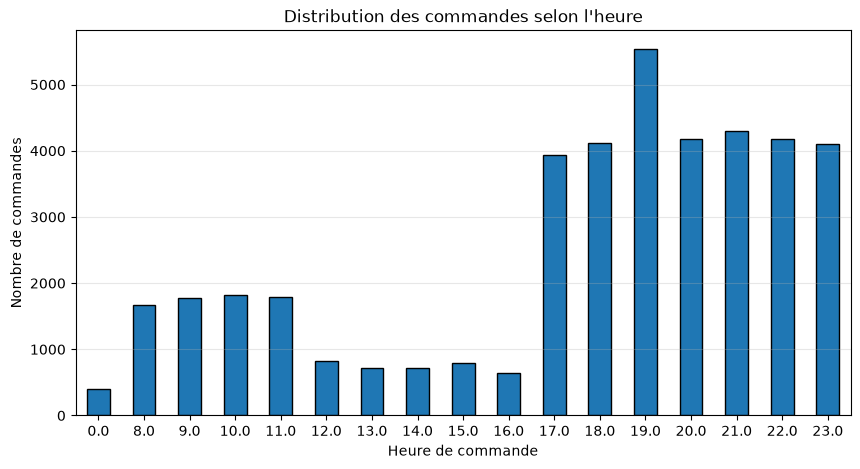

In [32]:
plt.figure(figsize=(10, 5))

clean_df["order_hour"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.xlabel("Heure de commande")
plt.ylabel("Nombre de commandes")
plt.title("Distribution des commandes selon l'heure")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

### 5.3.4 Analyse de l'heure de récupération

Nous allons analyser la répartition des commandes selon l'heure de récupération afin d'identifier les périodes les plus fréquentes.

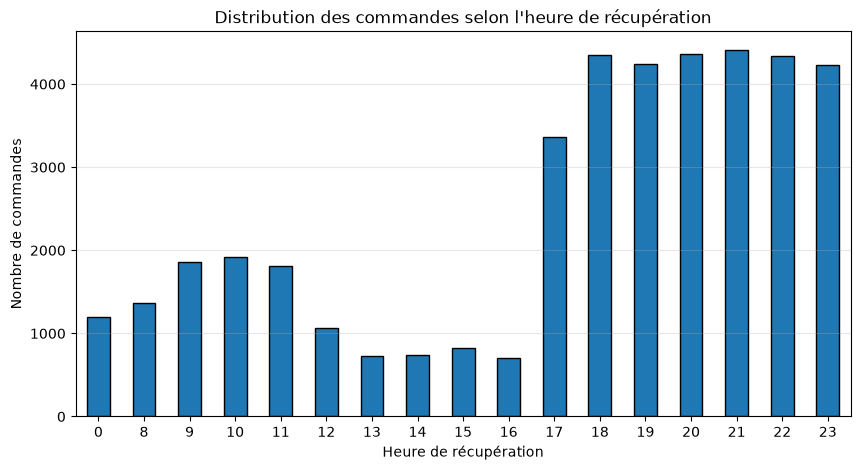

In [34]:
plt.figure(figsize=(10, 5))

clean_df["pickup_hour"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.xlabel("Heure de récupération")
plt.ylabel("Nombre de commandes")
plt.title("Distribution des commandes selon l'heure de récupération")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

### 5.3.5 Analyse de la distance de livraison

Nous allons analyser la distribution de la distance entre le restaurant et le lieu de livraison.

Cette analyse permet de comprendre les distances généralement parcourues et d'identifier d'éventuelles valeurs inhabituelles.

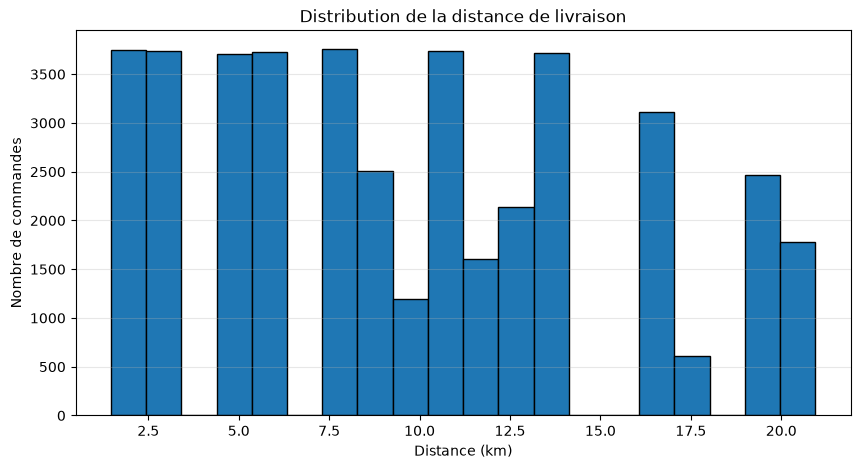

In [35]:
plt.figure(figsize=(10, 5))

plt.hist(
    clean_df["distance"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Distance (km)")
plt.ylabel("Nombre de commandes")
plt.title("Distribution de la distance de livraison")
plt.grid(axis="y", alpha=0.3)

plt.show()

### 5.4 Analyse des variables catégorielles

Nous allons maintenant analyser les variables catégorielles du dataset.

L'objectif est d'observer la fréquence de chaque catégorie et d'identifier les catégories les plus représentées dans les données.

Pour cette analyse, nous utiliserons des diagrammes en barres, adaptés à la comparaison de catégories.

In [36]:
clean_df["Weatherconditions"].value_counts()

Weatherconditions
Fog           7382
Stormy        6932
Cloudy        6881
Sandstorms    6853
Windy         6792
Sunny         6682
Name: count, dtype: int64

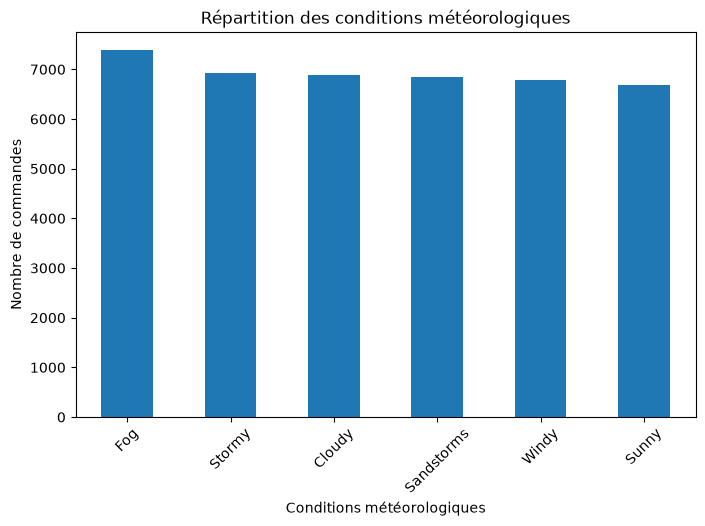

In [38]:

clean_df["Weatherconditions"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Conditions météorologiques")
plt.ylabel("Nombre de commandes")
plt.title("Répartition des conditions météorologiques")
plt.xticks(rotation=45)
plt.show()

In [41]:
clean_df["Type_of_vehicle"].value_counts()

Type_of_vehicle
motorcycle           24197
scooter              13878
electric_scooter      3404
bicycle                 43
Name: count, dtype: int64

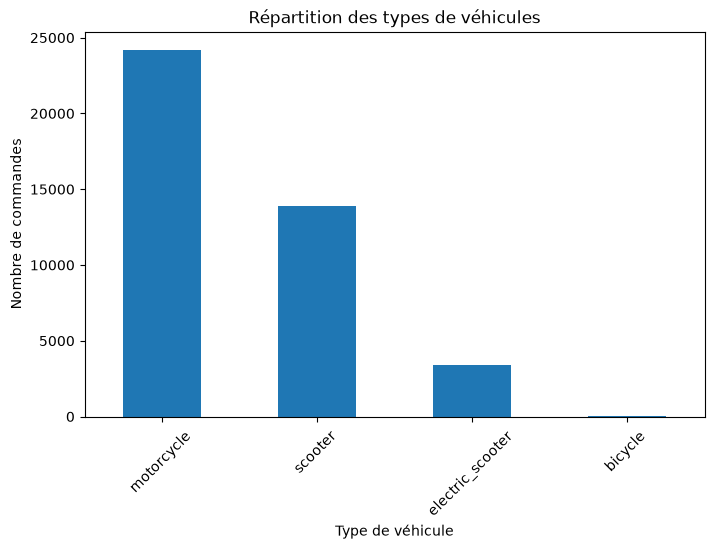

In [42]:
clean_df["Type_of_vehicle"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Type de véhicule")
plt.ylabel("Nombre de commandes")
plt.title("Répartition des types de véhicules")
plt.xticks(rotation=45)
plt.show()

In [43]:
clean_df["Road_traffic_density"].value_counts()

Road_traffic_density
Low        14095
Jam        12950
Medium     10023
High        4046
Unknown      408
Name: count, dtype: int64

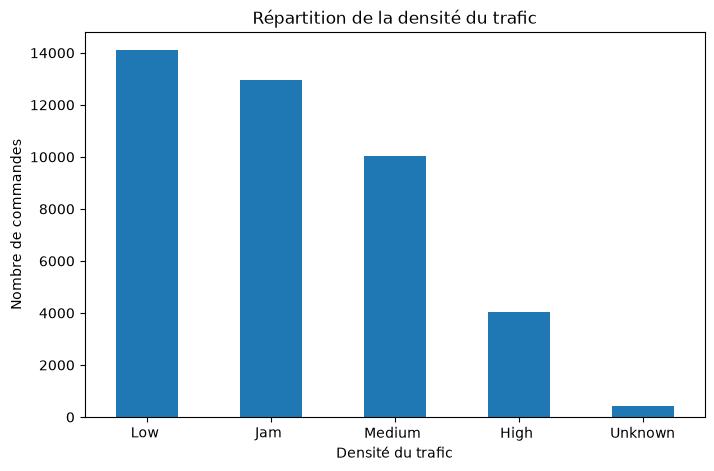

In [40]:
clean_df["Road_traffic_density"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Densité du trafic")
plt.ylabel("Nombre de commandes")
plt.title("Répartition de la densité du trafic")
plt.xticks(rotation=0)
plt.show()

In [45]:
clean_df["Road_traffic_density"].unique()

<ArrowStringArray>
['High ', 'Jam ', 'Low ', 'Medium ', 'Unknown']
Length: 5, dtype: str

In [4]:
clean_df["Road_traffic_density"].isna().sum()

np.int64(0)

In [5]:
clean_df["Road_traffic_density"] = (
    clean_df["Road_traffic_density"].str.strip()
)

In [7]:
clean_df["Road_traffic_density"].value_counts()

Road_traffic_density
Low       14503
Jam       12950
Medium    10023
High       4046
Name: count, dtype: int64

In [8]:
clean_df["Road_traffic_density"] = (
    clean_df["Road_traffic_density"].replace(
        "Unknown",
        clean_df["Road_traffic_density"].mode()[0]
    )
)

clean_df["Road_traffic_density"].value_counts()


Road_traffic_density
Low       14503
Jam       12950
Medium    10023
High       4046
Name: count, dtype: int64

###  Analyse du type de véhicule

Nous allons analyser la variable `Type_of_vehicle` afin d'observer la répartition des différents types de véhicules utilisés pour les livraisons.

In [51]:
clean_df["Type_of_vehicle"].value_counts()

Type_of_vehicle
motorcycle           24197
scooter              13878
electric_scooter      3404
bicycle                 43
Name: count, dtype: int64

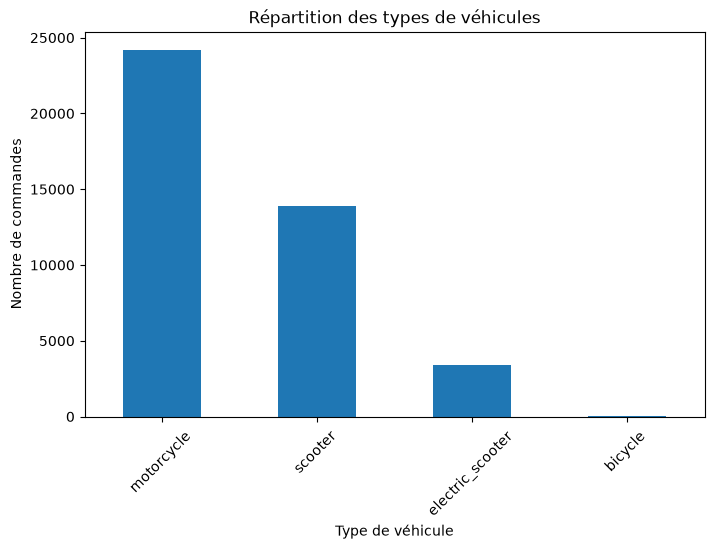

In [11]:
clean_df["Type_of_vehicle"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Type de véhicule")
plt.ylabel("Nombre de commandes")
plt.title("Répartition des types de véhicules")
plt.xticks(rotation=45)
plt.show()

### 5.5 Analyse des valeurs aberrantes

Nous allons maintenant rechercher les valeurs aberrantes dans les variables numériques.

Une valeur aberrante est une observation qui est très éloignée de la majorité des autres valeurs.

Nous utiliserons des boxplots pour identifier visuellement ces valeurs.

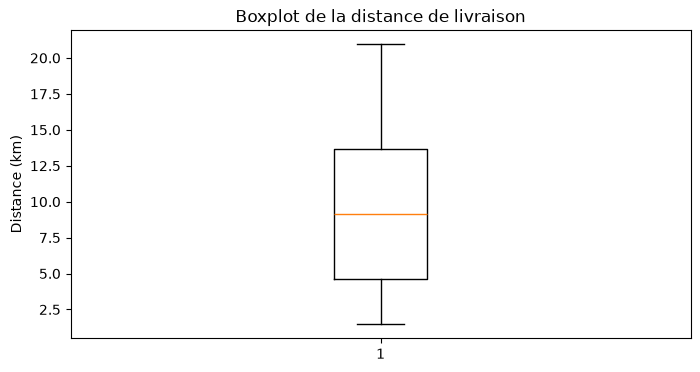

In [12]:
plt.figure(figsize=(8, 4))

plt.boxplot(clean_df["distance"])

plt.ylabel("Distance (km)")
plt.title("Boxplot de la distance de livraison")

plt.show()

In [14]:
clean_df["distance"].describe()

count    41522.000000
mean         9.704133
std          5.593935
min          1.463837
25%          4.648474
50%          9.177295
75%         13.659637
max         20.942906
Name: distance, dtype: float64

### 5.5.1 Analyse des valeurs aberrantes

Dans cette étape, nous allons rechercher les **valeurs aberrantes (outliers)** dans les variables numériques.

L'objectif est d'identifier les valeurs inhabituelles qui peuvent influencer l'analyse ou le futur modèle de machine learning.

Nous commencerons par analyser la variable `distance`.

In [15]:
Q1 = clean_df["distance"].quantile(0.25)
Q3 = clean_df["distance"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower bound :", lower_bound)
print("Upper bound :", upper_bound)

Q1 : 4.64847378122608
Q3 : 13.659636883890228
IQR : 9.011163102664147
Lower bound : -8.86827087277014
Upper bound : 27.17638153788645


In [ ]:
outliers = clean_df[
    (clean_df["distance"] < lower_bound) |
    (clean_df["distance"] > upper_bound)
]

print("Nombre d'outliers :", len(outliers))


Nombre d'outliers : 0


### 5.5.2 Analyse des valeurs aberrantes du temps de livraison

Nous allons maintenant analyser les valeurs aberrantes de la variable cible `Time_taken(min)`.

L'objectif est d'identifier les temps de livraison qui sont très éloignés de la majorité des observations.

Pour cela, nous utiliserons un boxplot et la méthode de l'IQR afin de déterminer les limites statistiques des valeurs normales.

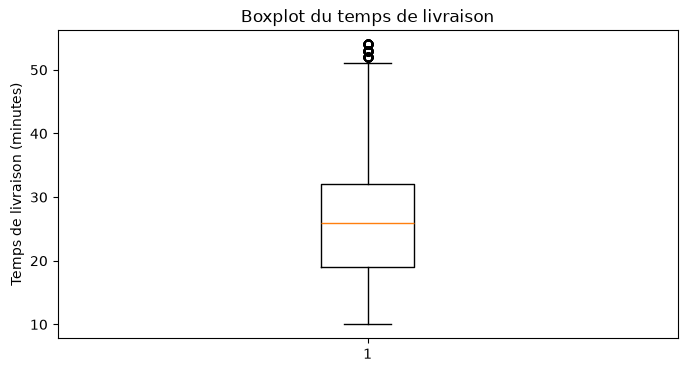

In [18]:
plt.figure(figsize=(8, 4))

plt.boxplot(clean_df["Time_taken(min)"])

plt.ylabel("Temps de livraison (minutes)")
plt.title("Boxplot du temps de livraison")

plt.show()

In [19]:
Q1 = clean_df["Time_taken(min)"].quantile(0.25)
Q3 = clean_df["Time_taken(min)"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR 


print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower bound :", lower_bound)
print("Upper bound :", upper_bound)

Q1 : 19.0
Q3 : 32.0
IQR : 13.0
Lower bound : -0.5
Upper bound : 51.5


In [22]:
outliers = clean_df[
    (clean_df["Time_taken(min)"] < lower_bound) |
    (clean_df["Time_taken(min)"] > upper_bound)
]

print("Nombre d'outliers :", len(outliers))
print(outliers.columns.tolist())


Nombre d'outliers : 243
['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Weatherconditions', 'Road_traffic_density', 'Type_of_vehicle', 'multiple_deliveries', 'Time_taken(min)', 'distance', 'order_hour', 'pickup_hour']


### 5.5.3 Analyse des valeurs aberrantes de l'âge

Nous allons maintenant analyser les valeurs aberrantes de la variable `Delivery_person_Age`.

L'objectif est de vérifier s'il existe des âges qui sont statistiquement éloignés de la majorité des observations.

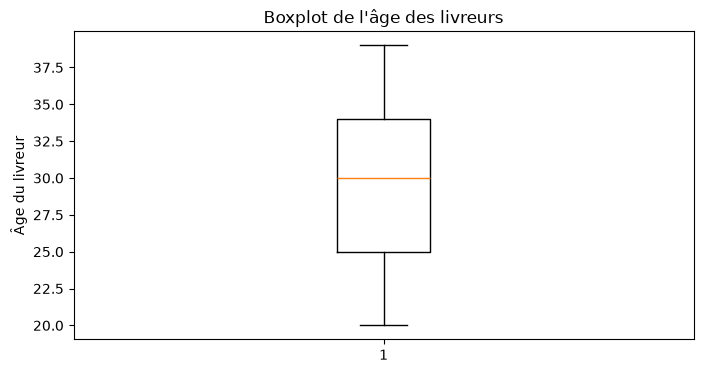

In [23]:

plt.figure(figsize=(8, 4))

plt.boxplot(clean_df["Delivery_person_Age"])

plt.ylabel("Âge du livreur")
plt.title("Boxplot de l'âge des livreurs")

plt.show()

In [24]:
Q1 = clean_df["Delivery_person_Age"].quantile(0.25)
Q3 = clean_df["Delivery_person_Age"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = clean_df[
    (clean_df["Delivery_person_Age"] < lower_bound) |
    (clean_df["Delivery_person_Age"] > upper_bound)
]

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower bound :", lower_bound)
print("Upper bound :", upper_bound)
print("Nombre d'outliers :", len(outliers))

Q1 : 25.0
Q3 : 34.0
IQR : 9.0
Lower bound : 11.5
Upper bound : 47.5
Nombre d'outliers : 0


### 5.5.5 Analyse des valeurs aberrantes de `multiple_deliveries`

Nous allons maintenant analyser la variable `multiple_deliveries` afin de vérifier la présence éventuelle de valeurs aberrantes.

Nous utiliserons un boxplot puis la méthode de l'IQR pour identifier les valeurs statistiquement inhabituelles.

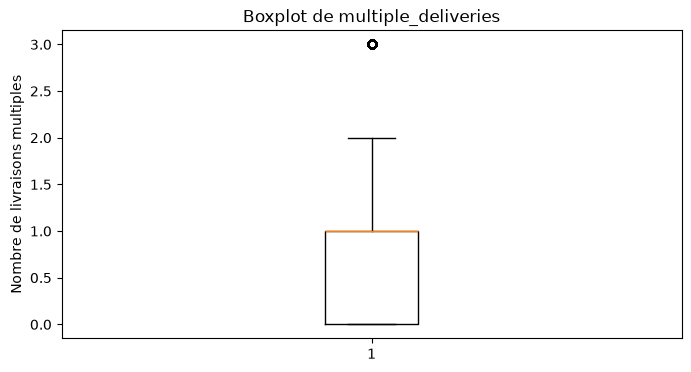

In [25]:
plt.figure(figsize=(8, 4))

plt.boxplot(clean_df["multiple_deliveries"])

plt.ylabel("Nombre de livraisons multiples")
plt.title("Boxplot de multiple_deliveries")

plt.show()

In [26]:
Q1 = clean_df["multiple_deliveries"].quantile(0.25)
Q3 = clean_df["multiple_deliveries"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = clean_df[
    (clean_df["multiple_deliveries"] < lower_bound) |
    (clean_df["multiple_deliveries"] > upper_bound)
]

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower bound :", lower_bound)
print("Upper bound :", upper_bound)
print("Nombre d'outliers :", len(outliers))

Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Lower bound : -1.5
Upper bound : 2.5
Nombre d'outliers : 323


#### Interprétation

La méthode de l'IQR identifie 323 valeurs aberrantes dans `multiple_deliveries`.

La borne supérieure est de 2,5. Ainsi, les observations ayant la valeur 3 sont considérées comme des outliers statistiques.

Cependant, la valeur 3 est une valeur valide présente dans le dataset et ne représente pas nécessairement une erreur.

Nous conservons donc ces observations afin de ne pas supprimer des informations potentiellement utiles pour la prédiction.

### 5.5.6 Analyse des valeurs aberrantes de `order_hour`

Nous allons maintenant analyser la variable `order_hour` afin de vérifier la présence éventuelle de valeurs aberrantes.

Cette variable représente l'heure à laquelle la commande a été passée. Nous utiliserons un boxplot et la méthode de l'IQR pour identifier les valeurs statistiquement inhabituelles.

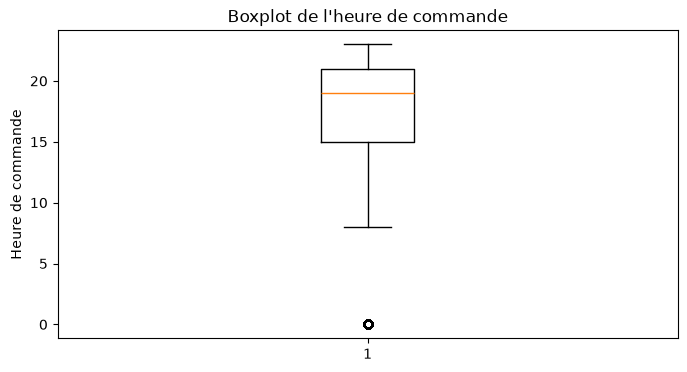

In [27]:
plt.figure(figsize=(8, 4))

plt.boxplot(clean_df["order_hour"])

plt.ylabel("Heure de commande")
plt.title("Boxplot de l'heure de commande")

plt.show()

In [28]:
Q1 = clean_df["order_hour"].quantile(0.25)
Q3 = clean_df["order_hour"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = clean_df[
    (clean_df["order_hour"] < lower_bound) |
    (clean_df["order_hour"] > upper_bound)
]

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower bound :", lower_bound)
print("Upper bound :", upper_bound)
print("Nombre d'outliers :", len(outliers))

Q1 : 15.0
Q3 : 21.0
IQR : 6.0
Lower bound : 6.0
Upper bound : 30.0
Nombre d'outliers : 395


### 5.5.7 Analyse des valeurs aberrantes de `pickup_hour`

Nous allons enfin analyser la variable `pickup_hour` afin de vérifier la présence éventuelle de valeurs inhabituelles.

Cette variable représente l'heure à laquelle la commande a été récupérée par le livreur. Nous utiliserons un boxplot et la méthode de l'IQR.

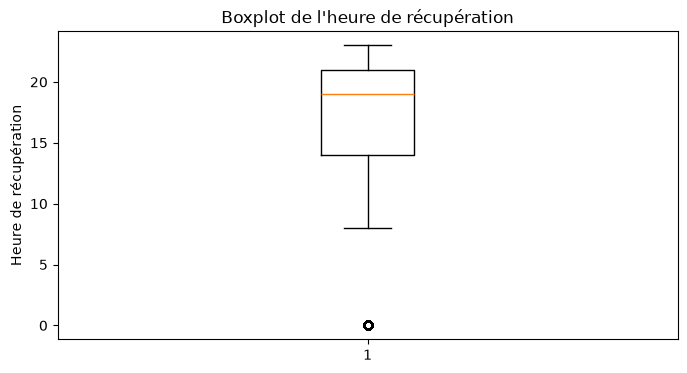

In [29]:
plt.figure(figsize=(8, 4))

plt.boxplot(clean_df["pickup_hour"])

plt.ylabel("Heure de récupération")
plt.title("Boxplot de l'heure de récupération")

plt.show()

In [30]:
Q1 = clean_df["pickup_hour"].quantile(0.25)
Q3 = clean_df["pickup_hour"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = clean_df[
    (clean_df["pickup_hour"] < lower_bound) |
    (clean_df["pickup_hour"] > upper_bound)
]

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower bound :", lower_bound)
print("Upper bound :", upper_bound)
print("Nombre d'outliers :", len(outliers))

Q1 : 14.0
Q3 : 21.0
IQR : 7.0
Lower bound : 3.5
Upper bound : 31.5
Nombre d'outliers : 1196


#### Interprétation

La méthode de l'IQR identifie 1 196 valeurs comme aberrantes dans `pickup_hour`.

Cependant, `pickup_hour` représente une heure de la journée comprise entre 0 et 23. Les valeurs inférieures à 3,5 sont donc des heures valides et ne représentent pas nécessairement des erreurs.

Nous conservons donc toutes les observations de cette variable et ne supprimons aucune valeur.

### 5.5.8 Conclusion de l'analyse des valeurs aberrantes

L'analyse des valeurs aberrantes a permis d'identifier les observations inhabituelles dans les variables numériques.

Certaines valeurs ont été considérées comme des outliers par la méthode de l'IQR. Cependant, elles ne représentent pas forcément des erreurs, notamment pour les variables `multiple_deliveries`, `order_hour` et `pickup_hour`.

Après vérification, nous avons décidé de conserver ces observations afin de ne pas supprimer des informations potentiellement utiles pour la prédiction du temps de livraison.